In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
data = np.random.randn(1000)
noise = np.random.randn(1000) * 0.5
signal = data + noise

print(f"Mean: {signal.mean():.4f}")
print(f"Std: {signal.std():.4f}")
print(f"Min: {signal.min():.4f}")
print(f"Max: {signal.max():.4f}")

Mean: -0.0035
Std: 1.1341
Min: -3.6027
Max: 3.4945


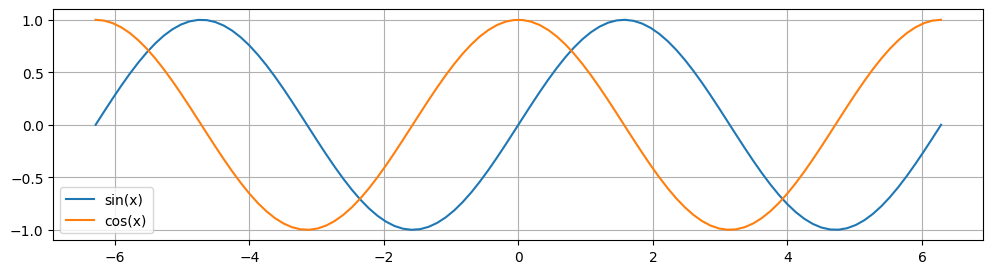

In [24]:
x = np.linspace(-2*np.pi, 2*np.pi, 100)
sin_wave = np.sin(x)
cos_wave = np.cos(x)

plt.figure(figsize=(12, 3))
plt.plot(x, sin_wave, label='sin(x)')
plt.plot(x, cos_wave, label='cos(x)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
img = Image.open('../img/rotation_image.png')
img_array = np.array(img)
img_array.shape # 4 channels (RGBA)

(512, 512, 4)

In [40]:
def apply_cos_distortion(image, amplitude=20, frequency=0.1):
    h, w = image.shape[:2]
    
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    
    displacement = amplitude * np.cos(frequency * Y)
    
    X_new = X + displacement
    X_new = np.clip(X_new, 0, w-1).astype(int)
    
    distorted = image[Y, X_new, :] if len(image.shape) == 3 else image[Y, X_new]
    
    return distorted

def apply_sin_distortion(image, amplitude=20, frequency=0.1):
    h, w = image.shape[:2]
    
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    
    displacement = amplitude * np.sin(frequency * X)
    
    Y_new = Y + displacement
    Y_new = np.clip(Y_new, 0, h-1).astype(int)
    
    distorted = image[Y_new, X, :] if len(image.shape) == 3 else image[Y_new, X]
    
    return distorted

img_cos = apply_cos_distortion(img_array, amplitude=50, frequency=0.07)
img_sin = apply_sin_distortion(img_array, amplitude=50, frequency=0.07)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..25.5].


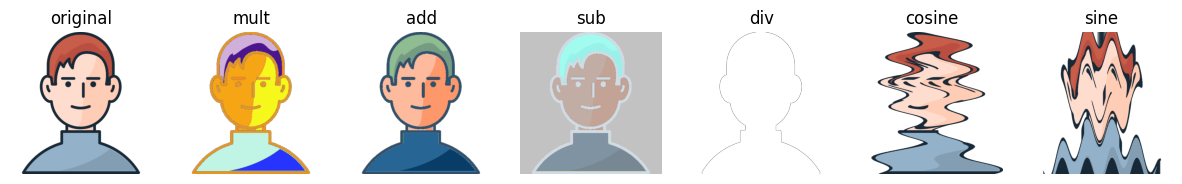

In [44]:
# original
plt.figure(figsize=(15, 4))
plt.subplot(171)
plt.imshow(img_array)
plt.title('original')
plt.axis('off')

# multiplication
plt.subplot(172) 
plt.imshow(img_array * 10) 
plt.title('mult')
plt.axis('off')

# addition
plt.subplot(173) 
plt.imshow(img_array + img_array) 
plt.title('add')
plt.axis('off')

# substract
plt.subplot(174) 
plt.imshow(img_array - 100) 
plt.title('sub')
plt.axis('off')

# division
plt.subplot(175) 
plt.imshow(img_array / 10) 
plt.title('div')
plt.axis('off')

# cos
plt.subplot(176) 
plt.imshow(img_cos) 
plt.title('cosine')
plt.axis('off')

# sin
plt.subplot(177) 
plt.imshow(img_sin) 
plt.title('sine')
plt.axis('off')

plt.savefig('007_math_operations', dpi=70)
plt.show()